# Mini-Projeto 2 - Controlador Fuzzy (Mamdani) para Compra Automotiva

**Caminho B** da especificacao: reescrita do **Mini-Projeto 1** (sistema baseado em regras IF-THEN nitidas em `experta`), trocando a pontuacao crisp por **inferencia fuzzy** com `scikit-fuzzy`.

## Motivacao
No MP1 a adequacao de cada carro era a **soma de fatos `Ponto`** (+1, -1, +0.5) disparados por **limiares abruptos**: `preco > orcamento` elimina, `seguranca < 4` elimina, `consumo == 'alto'` penaliza. Um carro a R$ 120.001 com orcamento de R$ 120.000 era tratado igual a um de R$ 300.000. Esses limiares sao **arbitrarios e frageis**.

Aqui a adequacao vira uma variavel **continua [0-100]** produzida por um controlador **Mamdani** com 3 entradas linguisticas e 14 regras fuzzy. A transicao entre "cabe no orcamento" e "caro" passa a ser **gradual**.

## Arquitetura
| Componente | MP1 (regras nitidas) | MP2 (fuzzy) |
|---|---|---|
| Entradas | fatos crisp + limiares `>`, `<`, `==` | variaveis linguisticas com funcoes de pertinencia |
| Inferencia | encadeamento progressivo (`experta`) | Mamdani (min/max) no `scikit-fuzzy` |
| Saida | soma de pontos discretos | adequacao defuzzificada (centroide) |
| Decisao | maior soma + desempate | maior adequacao |

**Premissa de projeto:** restricoes genuinamente **binarias** do dominio (categoria exigida, rejeicao a combustao) **permanecem crisp** como filtro de elegibilidade -- nao faz sentido fuzzificar "isto e um SUV". O fuzzy entra exatamente onde o MP1 usava limiares arbitrarios sobre grandezas **continuas** (preco, seguranca, economia).

In [1]:
# Em ambiente local use `uv` (ver README). No Google Colab, descomente:
# %pip install -q scikit-fuzzy networkx packaging
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
print('scikit-fuzzy', fuzz.__version__)

Matplotlib is building the font cache; this may take a moment.


scikit-fuzzy 0.5.0


## 1. Variaveis linguisticas e funcoes de pertinencia

**3 entradas** (>= 2 exigidas) e **1 saida**, cada uma com **3 termos** (minimo exigido), todos justificados pelo dominio:

- `preco_relativo` = `preco_carro / orcamento * 100` (% do orcamento). Termos **barato / no_orcamento / caro**. A faixa `no_orcamento` (~85-115%) expressa o "quase coube" que o corte rigido do MP1 nao tinha.
- `seguranca` = nota 0-5 (mesma escala do catalogo do MP1). Termos **baixa / media / alta**.
- `eficiencia` = indice 0-10 que combina consumo + custo de manutencao. Termos **ruim / mediana / otima**.
- `adequacao` (saida) = 0-100. Termos **rejeitar / considerar / recomendar**.

In [2]:
preco_rel  = ctrl.Antecedent(np.arange(0, 151, 1),     'preco_relativo')  # % do orcamento
seguranca  = ctrl.Antecedent(np.arange(0, 5.01, 0.05), 'seguranca')       # nota 0-5
eficiencia = ctrl.Antecedent(np.arange(0, 10.01, 0.05),'eficiencia')      # indice 0-10
adequacao  = ctrl.Consequent(np.arange(0, 101, 1),     'adequacao')       # 0-100

preco_rel['barato']       = fuzz.trapmf(preco_rel.universe, [0, 0, 55, 80])
preco_rel['no_orcamento'] = fuzz.trapmf(preco_rel.universe, [60, 85, 100, 115])
preco_rel['caro']         = fuzz.trapmf(preco_rel.universe, [100, 115, 150, 150])

seguranca['baixa'] = fuzz.trapmf(seguranca.universe, [0, 0, 2, 3.5])
seguranca['media'] = fuzz.trimf(seguranca.universe, [2.5, 3.5, 4.5])
seguranca['alta']  = fuzz.trapmf(seguranca.universe, [3.5, 4.5, 5, 5])

eficiencia['ruim']    = fuzz.trapmf(eficiencia.universe, [0, 0, 3, 5])
eficiencia['mediana'] = fuzz.trimf(eficiencia.universe, [3.5, 5.5, 7.5])
eficiencia['otima']   = fuzz.trapmf(eficiencia.universe, [6, 8, 10, 10])

adequacao['rejeitar']   = fuzz.trapmf(adequacao.universe, [0, 0, 20, 40])
adequacao['considerar'] = fuzz.trimf(adequacao.universe, [25, 50, 75])
adequacao['recomendar'] = fuzz.trapmf(adequacao.universe, [60, 80, 100, 100])
print('Variaveis e funcoes de pertinencia definidas.')

Variaveis e funcoes de pertinencia definidas.


/Users/davigurgel/Dev/controlador-fuzzy-automotivo/.venv/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


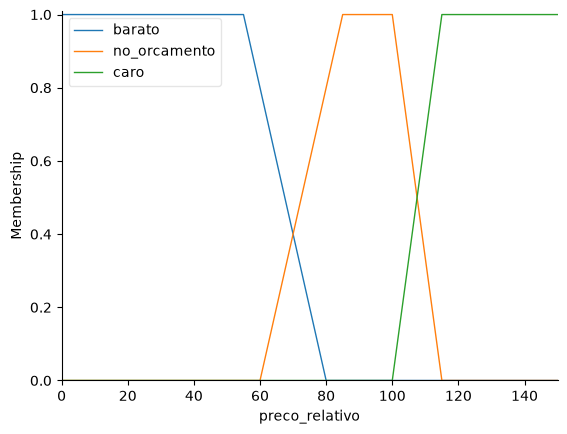

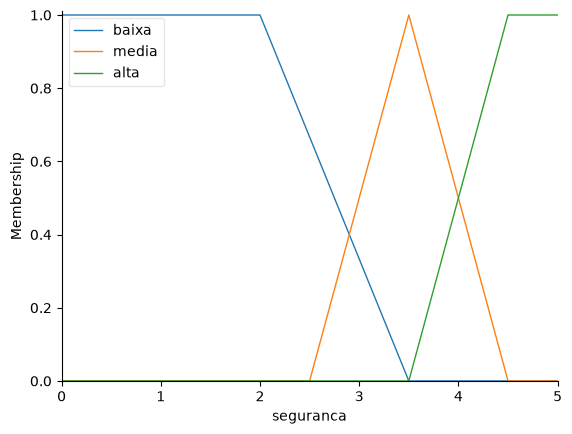

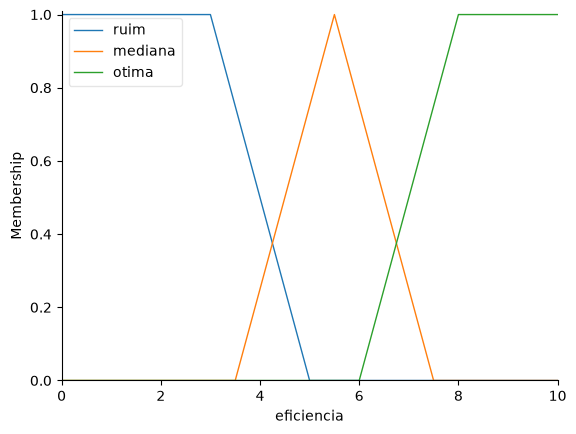

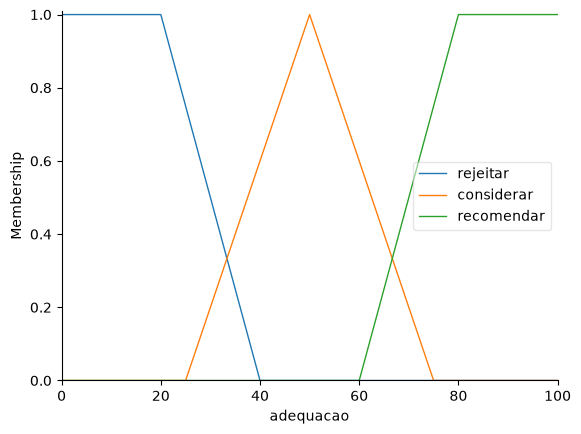

In [3]:
# Visualizacao das funcoes de pertinencia (opcional - requer matplotlib)
try:
    import matplotlib.pyplot as plt
    for var in (preco_rel, seguranca, eficiencia, adequacao):
        var.view()
    plt.show()
except Exception as e:
    print('matplotlib indisponivel, pulando graficos:', e)

## 2. Base de regras fuzzy (14 regras)

As **14 regras** cobrem as **3x3x3 = 27** combinacoes de termos das entradas **sem lacunas** (tabela de cobertura no README). O `&` e o AND (min), `~` e o NOT (complemento).

Logica: o **veto de orcamento** (`caro -> rejeitar`) e o **piso de seguranca** substituem os cortes R1/R3 do MP1; o restante gradua entre *considerar* e *recomendar* conforme preco, seguranca e eficiencia.

In [4]:
REGRAS = [
    ctrl.Rule(preco_rel['caro'], adequacao['rejeitar']),                                                  # R1 veto orcamento
    ctrl.Rule(seguranca['baixa'] & preco_rel['no_orcamento'], adequacao['rejeitar']),                     # R2 piso seguranca
    ctrl.Rule(seguranca['baixa'] & preco_rel['barato'], adequacao['considerar']),                         # R3
    ctrl.Rule(preco_rel['barato'] & seguranca['alta'] & eficiencia['otima'], adequacao['recomendar']),    # R4
    ctrl.Rule(preco_rel['barato'] & seguranca['alta'] & eficiencia['mediana'], adequacao['recomendar']),  # R5
    ctrl.Rule(preco_rel['no_orcamento'] & seguranca['alta'] & eficiencia['otima'], adequacao['recomendar']),  # R6
    ctrl.Rule(preco_rel['barato'] & seguranca['media'] & eficiencia['otima'], adequacao['recomendar']),   # R7
    ctrl.Rule(preco_rel['no_orcamento'] & seguranca['alta'] & eficiencia['mediana'], adequacao['considerar']),  # R8
    ctrl.Rule(preco_rel['no_orcamento'] & seguranca['media'] & eficiencia['otima'], adequacao['considerar']),   # R9
    ctrl.Rule(preco_rel['barato'] & seguranca['media'] & eficiencia['mediana'], adequacao['considerar']),       # R10
    ctrl.Rule(seguranca['media'] & eficiencia['ruim'] & ~preco_rel['caro'], adequacao['considerar']),           # R11
    ctrl.Rule(preco_rel['barato'] & seguranca['alta'] & eficiencia['ruim'], adequacao['considerar']),           # R12
    ctrl.Rule(preco_rel['no_orcamento'] & seguranca['media'] & eficiencia['mediana'], adequacao['considerar']), # R13
    ctrl.Rule(preco_rel['no_orcamento'] & seguranca['alta'] & eficiencia['ruim'], adequacao['considerar']),     # R14
]
SISTEMA = ctrl.ControlSystem(REGRAS)
print(f'{len(REGRAS)} regras carregadas no controlador Mamdani.')

def avaliar(preco_relativo, nota_seguranca, indice_eficiencia):
    """Roda o Mamdani e devolve a adequacao defuzzificada (centroide)."""
    sim = ctrl.ControlSystemSimulation(SISTEMA)
    sim.input['preco_relativo'] = float(np.clip(preco_relativo, 0, 150))
    sim.input['seguranca']      = float(nota_seguranca)
    sim.input['eficiencia']     = float(indice_eficiencia)
    sim.compute()
    return float(sim.output['adequacao'])

14 regras carregadas no controlador Mamdani.


## 3. Casos de teste do controlador (entradas -> saida -> interpretacao)

Tres casos diretos exigidos pela rubrica, com **entradas, saida defuzzificada e interpretacao comentada**.

In [5]:
# [A] Carro 'dos sonhos' dentro do orcamento: barato, seguranca e eficiencia maximas
a = avaliar(preco_relativo=60, nota_seguranca=5, indice_eficiencia=9)
print(f'[A] preco_rel=60%  seg=5.0  ef=9.0  ->  adequacao = {a:.1f}')
# Interpretacao: dispara R4 (barato & alta & otima => recomendar) com forca alta;
# o centroide cai na regiao 'recomendar' (~84). Compra ideal.
assert a > 75

# [B] Acima do orcamento, mesmo otimo no resto -> o veto domina
b = avaliar(preco_relativo=130, nota_seguranca=5, indice_eficiencia=9)
print(f'[B] preco_rel=130% seg=5.0  ef=9.0  ->  adequacao = {b:.1f}')
# Interpretacao: R1 (caro => rejeitar) domina e veta o veiculo apesar de seg/ef
# maximas; centroide em 'rejeitar' (~16). Equivale ao corte R1 do MP1, porem
# de forma graduada (um carro a 105% nao seria vetado tao duramente quanto a 130%).
assert b < 30

# [C] Caso de fronteira / intermediario
c = avaliar(preco_relativo=95, nota_seguranca=3.5, indice_eficiencia=5.5)
print(f'[C] preco_rel=95%  seg=3.5  ef=5.5  ->  adequacao = {c:.1f}')
# Interpretacao: nenhum extremo; R13 (no_orcamento & media & mediana => considerar)
# lidera. Centroide no meio (~50): 'da pra considerar'. Um SBC crisp precisaria de
# um limiar artificial para decidir exatamente aqui.
assert 35 < c < 65
print('\n3 casos de teste do controlador OK.')

[A] preco_rel=60%  seg=5.0  ef=9.0  ->  adequacao = 83.7
[B] preco_rel=130% seg=5.0  ef=9.0  ->  adequacao = 15.6
[C] preco_rel=95%  seg=3.5  ef=5.5  ->  adequacao = 50.0

3 casos de teste do controlador OK.


## 4. Aplicacao ao catalogo (mesmos perfis do MP1)

O catalogo e o mapeamento crisp->indice de eficiencia sao identicos ao MP1. Cada carro elegivel e pontuado pelo controlador; recomenda-se o de **maior adequacao**.

In [6]:
CONSUMO_SCORE = {'baixo': 9, 'medio': 5, 'alto': 1}
MANUT_SCORE   = {'baixa': 9, 'media': 5, 'alta': 1}

CATALOGO = [
    dict(modelo='Hatch Hibrido Compacto', preco=115000, categoria='hatch', consumo='baixo', manutencao='baixa', seguranca=5, motor='hibrido'),
    dict(modelo='Hatch Entrada Seguro',   preco=78000,  categoria='hatch', consumo='medio', manutencao='baixa', seguranca=5, motor='combustao'),
    dict(modelo='Hatch Popular Basico',   preco=72000,  categoria='hatch', consumo='medio', manutencao='baixa', seguranca=3, motor='combustao'),
    dict(modelo='Sedan Familiar',         preco=135000, categoria='sedan', consumo='medio', manutencao='media', seguranca=4, motor='combustao'),
    dict(modelo='SUV Espacoso Seguro',    preco=185000, categoria='SUV',   consumo='medio', manutencao='media', seguranca=5, motor='combustao'),
    dict(modelo='SUV Pesado Luxo',        preco=230000, categoria='SUV',   consumo='alto',  manutencao='alta',  seguranca=5, motor='combustao'),
    dict(modelo='SUV Hibrido Urbano',     preco=198000, categoria='SUV',   consumo='baixo', manutencao='baixa', seguranca=5, motor='hibrido'),
]

def indice_eficiencia(carro):
    return (CONSUMO_SCORE[carro['consumo']] + MANUT_SCORE[carro['manutencao']]) / 2.0

def elegivel(carro, perfil):
    """Restricoes binarias permanecem crisp (categoria, rejeicao a combustao)."""
    cat = perfil.get('categoria_exigida')
    if cat not in (None, '', 'qualquer') and carro['categoria'] != cat:
        return False, f"categoria {carro['categoria']} != {cat}"
    if perfil.get('rejeita_combustao') and carro['motor'] == 'combustao':
        return False, 'rejeita combustao'
    return True, ''

def recomendar(nome, perfil, mp1_escolheu=None):
    print(f'\n=== {nome} ===')
    print(f"Perfil: orcamento R$ {perfil['orcamento']:,} | categoria={perfil.get('categoria_exigida')} | rejeita_combustao={perfil.get('rejeita_combustao', False)}")
    ranking = []
    for carro in CATALOGO:
        ok, motivo = elegivel(carro, perfil)
        if not ok:
            print(f"  [x] {carro['modelo']:<24} eliminado ({motivo})")
            continue
        pr = carro['preco'] / perfil['orcamento'] * 100.0
        ef = indice_eficiencia(carro)
        ranking.append((avaliar(pr, carro['seguranca'], ef), carro, pr, ef))
    ranking.sort(key=lambda t: t[0], reverse=True)
    print('  Ranking fuzzy (adequacao 0-100):')
    for score, carro, pr, ef in ranking:
        print(f"    {carro['modelo']:<24} adequacao={score:5.1f}  (preco_rel={pr:5.1f}%, seg={carro['seguranca']}, ef={ef:.1f})")
    if ranking:
        venc = ranking[0][1]['modelo']
        print(f'  >> Recomendacao fuzzy: {venc} (adequacao {ranking[0][0]:.1f})')
        if mp1_escolheu:
            print('     [vs MP1:', 'IGUAL]' if venc == mp1_escolheu else f'DIFERE -> MP1 escolheu {mp1_escolheu}]')
    return ranking

_ = recomendar('Caso 1 - Urbano/economia, orc 120k', dict(orcamento=120000, categoria_exigida='qualquer', rejeita_combustao=False), 'Hatch Hibrido Compacto')
_ = recomendar('Caso 2 - Familia/viagem, SUV, orc 200k', dict(orcamento=200000, categoria_exigida='SUV', rejeita_combustao=False), 'SUV Espacoso Seguro')
_ = recomendar('Caso 3 - Orcamento baixo 80k, hatch', dict(orcamento=80000, categoria_exigida='hatch', rejeita_combustao=False), 'Hatch Entrada Seguro')
_ = recomendar('Caso 4 - Rejeita combustao, SUV, orc 210k', dict(orcamento=210000, categoria_exigida='SUV', rejeita_combustao=True), 'SUV Hibrido Urbano')


=== Caso 1 - Urbano/economia, orc 120k ===
Perfil: orcamento R$ 120,000 | categoria=qualquer | rejeita_combustao=False
  Ranking fuzzy (adequacao 0-100):
    Hatch Hibrido Compacto   adequacao= 84.4  (preco_rel= 95.8%, seg=5, ef=9.0)
    Hatch Entrada Seguro     adequacao= 71.7  (preco_rel= 65.0%, seg=5, ef=7.0)
    Hatch Popular Basico     adequacao= 68.1  (preco_rel= 60.0%, seg=3, ef=7.0)
    Sedan Familiar           adequacao= 23.3  (preco_rel=112.5%, seg=4, ef=5.0)
    SUV Espacoso Seguro      adequacao= 15.6  (preco_rel=154.2%, seg=5, ef=5.0)
    SUV Pesado Luxo          adequacao= 15.6  (preco_rel=191.7%, seg=5, ef=1.0)
    SUV Hibrido Urbano       adequacao= 15.6  (preco_rel=165.0%, seg=5, ef=9.0)
  >> Recomendacao fuzzy: Hatch Hibrido Compacto (adequacao 84.4)
     [vs MP1: IGUAL]

=== Caso 2 - Familia/viagem, SUV, orc 200k ===
Perfil: orcamento R$ 200,000 | categoria=SUV | rejeita_combustao=False
  [x] Hatch Hibrido Compacto   eliminado (categoria hatch != SUV)
  [x] Hatch En

## 5. Comparativo fuzzy x regras do MP1

**3 de 4 cenarios coincidem** com o MP1. O **Caso 2 diverge** de forma reveladora: o MP1, com regras discretas que premiavam porta-malas grande para familia/viagem, escolheu o *SUV Espacoso Seguro* (combustao, 520 L). O fuzzy, valorizando **eficiencia** de forma continua, prefere o *SUV Hibrido Urbano* (hibrido, no orcamento, seguranca maxima) -- uma escolha igualmente plausivel.

**Complexidade e expressividade:**
- **MP1 (nitido):** ~11 regras + `salience` + fases + fatos `Eliminado`/`Ponto` para orquestrar a ordem de disparo e evitar dupla contagem. A logica de *desempate* e *acumulacao* e codigo imperativo.
- **MP2 (fuzzy):** 14 regras declarativas, **sem controle de ordem** (a inferencia Mamdani agrega tudo automaticamente). Limiares arbitrarios (`> 400 L`, `< 4`, `preco > orcamento`) viram **transicoes suaves** -- maior poder de expressar "quase coube no orcamento" ou "seguranca razoavel".
- **Trade-off:** o fuzzy perde a *rastreabilidade regra-a-regra* (o MP1 dizia exatamente qual regra deu cada ponto) e exige calibrar as funcoes de pertinencia; ganha **robustez a ruido** e ausencia de descontinuidades nas decisoes de fronteira.